# 11 - MLB Pitch-Mix + Bullpen Focused Model Lab

This notebook is a leakage-safe follow-up to notebook 10. It focuses the modeling run on the feature families you asked about:

- `old_statcast_no_pitchmix_bullpen`
- `true_pitchmix`
- `true_bullpen_availability`
- `pitchmix_plus_bullpen`
- `old_statcast_plus_pitchmix_bullpen`
- `all_clean`

The key difference from the prior version: `MODEL_FEATURE_FAMILIES` is defined immediately after the feature-family summary, and the model loop trains **only** those selected families.


In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    log_loss,
    brier_score_loss,
    roc_auc_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import ParameterSampler

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    print('XGBoost unavailable:', repr(e))

try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except Exception as e:
    LIGHTGBM_AVAILABLE = False
    print('LightGBM unavailable:', repr(e))

RANDOM_STATE = 42
TARGET_COL = 'target_home_win'

## 1. Locate project root and load feature parquet

In [2]:
def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd] + list(cwd.parents):
        if (p / 'data').exists() and ((p / 'scripts').exists() or (p / 'notebooks').exists()):
            return p
    return cwd

PROJECT_ROOT = find_project_root()
FEATURES_PATH = PROJECT_ROOT / 'data' / 'processed' / 'mlb_game_features.parquet'

print('PROJECT_ROOT:', PROJECT_ROOT)
print('FEATURES_PATH:', FEATURES_PATH)
assert FEATURES_PATH.exists(), f'Missing feature file: {FEATURES_PATH}'

features = pd.read_parquet(FEATURES_PATH)
features['official_date'] = pd.to_datetime(features['official_date'])

print('Rows:', len(features))
print('Columns:', len(features.columns))
print('All official_date range:', features['official_date'].min(), 'to', features['official_date'].max())

completed_raw = features[features[TARGET_COL].notna()].copy()
unresolved = features[features[TARGET_COL].isna()].copy()

print('Completed/labeled rows:', len(completed_raw))
print('Completed date range:', completed_raw['official_date'].min(), 'to', completed_raw['official_date'].max())
print('Unresolved rows:', len(unresolved))
if len(unresolved):
    print('Unresolved date range:', unresolved['official_date'].min(), 'to', unresolved['official_date'].max())

PROJECT_ROOT: C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app
FEATURES_PATH: C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\data\processed\mlb_game_features.parquet
Rows: 9293
Columns: 4887
All official_date range: 2022-08-02 00:00:00 to 2026-09-22 00:00:00
Completed/labeled rows: 9089
Completed date range: 2022-08-02 00:00:00 to 2026-06-02 00:00:00
Unresolved rows: 204
Unresolved date range: 2024-09-29 00:00:00 to 2026-09-22 00:00:00


## 2. True scoring candidates sanity check

`target_home_win.isna()` means unresolved/unlabeled, not necessarily upcoming. This cell identifies actual near-term scoring candidates separately from stale historical unresolved rows and far-future schedule rows.


In [3]:
from datetime import timedelta

AS_OF_DATE = pd.Timestamp.today(tz='America/Chicago').date()
DAYS_FORWARD_SCORING = 2

unresolved = unresolved.copy()
unresolved['official_date_dt'] = pd.to_datetime(unresolved['official_date']).dt.date

start_date = AS_OF_DATE
end_date = AS_OF_DATE + timedelta(days=DAYS_FORWARD_SCORING)

date_mask = (unresolved['official_date_dt'] >= start_date) & (unresolved['official_date_dt'] <= end_date)
status_mask = pd.Series(True, index=unresolved.index)

if 'abstract_state' in unresolved.columns:
    status_mask &= unresolved['abstract_state'].astype(str).str.lower().isin(['preview', 'live'])
if 'detailed_state' in unresolved.columns:
    bad_states = 'postponed|cancelled|canceled|suspended|final'
    status_mask &= ~unresolved['detailed_state'].astype(str).str.lower().str.contains(bad_states, na=False)

scoring_candidates = unresolved[date_mask & status_mask].copy()
historical_unresolved = unresolved[unresolved['official_date_dt'] < start_date].copy()
far_future_unresolved = unresolved[unresolved['official_date_dt'] > end_date].copy()

print('AS_OF_DATE:', AS_OF_DATE)
print('Scoring candidate rows:', len(scoring_candidates))
if len(scoring_candidates):
    print('Scoring candidate range:', scoring_candidates['official_date_dt'].min(), 'to', scoring_candidates['official_date_dt'].max())
print('Historical unresolved rows:', len(historical_unresolved))
print('Far future unresolved rows:', len(far_future_unresolved))

display_cols = [c for c in [
    'game_pk', 'official_date', 'game_datetime_utc', 'away_team_name', 'home_team_name',
    'abstract_state', 'detailed_state'
] if c in scoring_candidates.columns]

display(scoring_candidates[display_cols].sort_values(['official_date', 'game_datetime_utc']).head(30))

AS_OF_DATE: 2026-06-04
Scoring candidate rows: 39
Scoring candidate range: 2026-06-04 to 2026-06-06
Historical unresolved rows: 16
Far future unresolved rows: 149


,game_pk,official_date,game_datetime_utc,away_team_name,home_team_name,abstract_state,detailed_state
9109,823457,2026-06-04,2026-06-04 17:05:00+00:00,San Diego Padres,Philadelphia Phillies,Preview,Scheduled
9110,823542,2026-06-04,2026-06-04 17:35:00+00:00,Cleveland Guardians,New York Yankees,Preview,Scheduled
9111,824753,2026-06-04,2026-06-04 17:35:00+00:00,Baltimore Orioles,Boston Red Sox,Preview,Scheduled
9112,823779,2026-06-04,2026-06-04 18:10:00+00:00,San Francisco Giants,Milwaukee Brewers,Preview,Scheduled
9113,824919,2026-06-04,2026-06-04 23:15:00+00:00,Toronto Blue Jays,Atlanta Braves,Preview,Scheduled
9114,823698,2026-06-04,2026-06-04 23:40:00+00:00,Kansas City Royals,Minnesota Twins,Preview,Scheduled
9115,824672,2026-06-04,2026-06-05 00:05:00+00:00,Athletics,Chicago Cubs,Preview,Scheduled
9116,824185,2026-06-04,2026-06-05 00:10:00+00:00,Pittsburgh Pirates,Houston Astros,Preview,Scheduled
9117,825076,2026-06-04,2026-06-05 01:40:00+00:00,Los Angeles Dodgers,Arizona Diamondbacks,Preview,Scheduled
9118,824673,2026-06-05,2026-06-05 18:20:00+00:00,San Francisco Giants,Chicago Cubs,Preview,Scheduled


## 3. Modeling window

In [4]:
# Keep 2022-08-01 if you want to use the full current parquet.
# Change to '2023-01-01' for a stricter modern-era-only model.
MIN_TRAIN_DATE = '2022-08-01'

completed_i = completed_raw.copy()
completed_i = completed_i[completed_i['official_date'] >= pd.Timestamp(MIN_TRAIN_DATE)].copy()
completed_i[TARGET_COL] = completed_i[TARGET_COL].astype(int)

print('Modeling rows:', len(completed_i))
print('Modeling date range:', completed_i['official_date'].min(), 'to', completed_i['official_date'].max())
print('Target home-win rate:', completed_i[TARGET_COL].mean())

Modeling rows: 9089
Modeling date range: 2022-08-02 00:00:00 to 2026-06-02 00:00:00
Target home-win rate: 0.5305314115964352


## 4. Leakage-safe feature selection

Raw final-score columns are used only for labels/evaluation and must not enter the model. Rolling/pre-game versions like `_last20`, `_season_to_date`, and `_pre` are allowed.


In [5]:
LEAKY_COLS_EXACT = {
    'home_score',
    'away_score',
    'diff_score',
    'home_margin',
    TARGET_COL,
}

metadata_cols = {
    'game_pk',
    'run_id',
    'scored_at_utc',
    'official_date',
    'official_date_dt',
    'game_datetime_utc',
    'home_team_name',
    'away_team_name',
    'home_team_id',
    'away_team_id',
    'venue_name',
    'abstract_state',
    'detailed_state',
}

rolling_tokens = [
    '_last1', '_last3', '_last5', '_last10', '_last20', '_last40',
    '_season_to_date', '_pre'
]

def is_probably_leaky_feature(col: str) -> bool:
    c = col.lower()

    if c in LEAKY_COLS_EXACT:
        return True

    hard_patterns = [
        'winner', 'winning', 'losing', 'final', 'result', 'outcome', 'actual', 'post_'
    ]
    if any(p in c for p in hard_patterns):
        return True

    if c.endswith('_id') or c in metadata_cols:
        return True

    # Same-game raw boxscore fields are leakage unless explicitly rolling/pregame.
    if c.startswith(('home_team_box_', 'away_team_box_', 'diff_team_box_')):
        if not any(tok in c for tok in rolling_tokens):
            return True

    return False

candidate_feature_cols = [
    c for c in completed_i.columns
    if c not in metadata_cols
    and c != TARGET_COL
    and pd.api.types.is_numeric_dtype(completed_i[c])
]

clean_feature_cols = [c for c in candidate_feature_cols if not is_probably_leaky_feature(c)]

print('Candidate feature count:', len(candidate_feature_cols))
print('Clean feature count:', len(clean_feature_cols))
removed_features = sorted(set(candidate_feature_cols) - set(clean_feature_cols))
display(pd.Series(removed_features, name='removed_features').head(200))

Candidate feature count: 4864
Clean feature count: 4829


0                        away_score
1           away_team_box_bb_per_ab
2       away_team_box_games_to_date
3           away_team_box_hr_per_ab
4            away_team_box_k_per_ab
5         away_team_box_lob_per_run
6         away_team_box_sb_attempts
7     away_team_box_sb_success_rate
8                 away_team_box_xbh
9         away_team_box_xbh_per_hit
10                       diff_score
11          diff_team_box_bb_per_ab
12      diff_team_box_games_to_date
13          diff_team_box_hr_per_ab
14           diff_team_box_k_per_ab
15        diff_team_box_lob_per_run
16        diff_team_box_sb_attempts
17    diff_team_box_sb_success_rate
18                diff_team_box_xbh
19        diff_team_box_xbh_per_hit
20                     diff_team_id
21                      home_margin
22                       home_score
23          home_team_box_bb_per_ab
24      home_team_box_games_to_date
25          home_team_box_hr_per_ab
26           home_team_box_k_per_ab
27        home_team_box_lob_

### Optional single-feature leakage audit

Anything with single-feature AUC near 1.0 is likely leaking the answer. After removing `home_score`, `away_score`, `diff_score`, and `home_margin`, the top single-column AUCs should be plausible rather than perfect.


In [6]:
RUN_LEAKAGE_AUDIT = True

if RUN_LEAKAGE_AUDIT:
    single_feature_auc = []
    y_audit = completed_i[TARGET_COL].astype(int)

    for c in clean_feature_cols:
        s = completed_i[c]
        tmp = pd.DataFrame({'x': s, 'y': y_audit}).dropna()
        if tmp['x'].nunique() < 2 or tmp['y'].nunique() < 2:
            continue
        try:
            auc = roc_auc_score(tmp['y'], tmp['x'])
            auc = max(auc, 1 - auc)
            single_feature_auc.append((c, auc, len(tmp), tmp['x'].nunique()))
        except Exception:
            pass

    single_feature_auc = (
        pd.DataFrame(single_feature_auc, columns=['feature', 'single_feature_auc', 'n', 'n_unique'])
        .sort_values('single_feature_auc', ascending=False)
    )
    display(single_feature_auc.head(100))
else:
    print('Set RUN_LEAKAGE_AUDIT=True to run the single-feature leakage audit.')

,feature,single_feature_auc,n,n_unique
4790,diff_starter_pitchtype_other_sc_pitch_type_p90...,1.000000,6,6
4791,diff_starter_pitchtype_other_sc_pitch_type_p90...,1.000000,6,6
4786,diff_starter_pitchtype_other_sc_pitch_type_avg...,1.000000,6,6
4785,diff_starter_pitchtype_other_sc_pitch_type_avg...,1.000000,6,6
4792,diff_starter_pitchtype_other_sc_pitch_type_p90...,1.000000,6,6
...,...,...,...,...
278,diff_team_box_ops_last10,0.552970,9074,5006
14,home_runs_against_season_to_date,0.552819,9074,7810
2160,diff_bullpen_sc_csw_rate_season_to_date,0.552705,9058,9055
47,away_elo_pre,0.552696,9089,9054


## 5. Chronological split and baseline

In [7]:
def chronological_split(df: pd.DataFrame, test_frac: float = 0.20):
    sort_cols = [c for c in ['official_date', 'game_datetime_utc', 'game_pk'] if c in df.columns]
    df = df.sort_values(sort_cols).reset_index(drop=True)
    split_idx = int(len(df) * (1 - test_frac))
    return df.iloc[:split_idx].copy(), df.iloc[split_idx:].copy()

train_df, test_df = chronological_split(completed_i, test_frac=0.20)
y_train = train_df[TARGET_COL].astype(int)
y_test = test_df[TARGET_COL].astype(int)

print('Train rows:', len(train_df), train_df['official_date'].min(), 'to', train_df['official_date'].max())
print('Test rows:', len(test_df), test_df['official_date'].min(), 'to', test_df['official_date'].max())

baseline_train_rate = y_train.mean()
baseline_probs = np.repeat(baseline_train_rate, len(y_test))

baseline_metrics = {
    'model_name': 'constant_train_home_rate',
    'feature_count': 0,
    'n_test': len(y_test),
    'avg_pred': float(baseline_probs.mean()),
    'actual_rate': float(y_test.mean()),
    'log_loss': float(log_loss(y_test, baseline_probs)),
    'brier': float(brier_score_loss(y_test, baseline_probs)),
    'roc_auc': 0.5,
    'accuracy_50pct': float(accuracy_score(y_test, baseline_probs >= 0.5)),
    'suspicious_metric': False,
}

display(pd.DataFrame([baseline_metrics]))

Train rows: 7271 2022-08-02 00:00:00 to 2025-07-23 00:00:00
Test rows: 1818 2025-07-23 00:00:00 to 2026-06-02 00:00:00


,model_name,feature_count,n_test,avg_pred,actual_rate,log_loss,brier,roc_auc,accuracy_50pct,suspicious_metric
0,constant_train_home_rate,0,1818,0.530876,0.529153,0.691452,0.249153,0.5,0.529153,False


## 6. Missingness filter

Missingness thresholds are learned from the train split only. The model pipeline still adds missingness indicators via `SimpleImputer(add_indicator=True)`.


In [8]:
DROP_IF_MISSING_GT = 0.40

manual_drop_cols = {
    'diff_team_box_sb_success_rate',
    'home_team_box_sb_success_rate',
    'away_team_box_sb_success_rate',
}

missing_pct_train = train_df[clean_feature_cols].isna().mean().sort_values(ascending=False)
high_missing_cols = set(missing_pct_train[missing_pct_train > DROP_IF_MISSING_GT].index)

model_base_cols = [
    c for c in clean_feature_cols
    if c not in high_missing_cols
    and c not in manual_drop_cols
    and c in train_df.columns
]

print('Clean feature count:', len(clean_feature_cols))
print('Dropped high-missing columns:', len(high_missing_cols))
print('Model base columns:', len(model_base_cols))

display(missing_pct_train.head(75).to_frame('missing_pct'))

Clean feature count: 4829
Dropped high-missing columns: 419
Model base columns: 4410


,missing_pct
diff_starter_pitchtype_other_sc_pitch_type_avg_ev_allowed_season_to_date,0.999725
diff_starter_pitchtype_other_sc_pitch_type_p90_batted_ball_distance_allowed_season_to_date,0.999725
diff_starter_pitchtype_other_sc_pitch_type_p90_batted_ball_distance_allowed_last3,0.999725
diff_starter_pitchtype_other_sc_pitch_type_p90_batted_ball_distance_allowed_last5,0.999725
diff_starter_pitchtype_other_sc_pitch_type_p90_batted_ball_distance_allowed_last10,0.999725
...,...
home_starter_pitchtype_other_sc_pitch_type_xwoba_allowed_contact_season_to_date,0.990648
home_starter_pitchtype_other_sc_pitch_type_xwoba_allowed_contact_last20,0.990648
away_starter_pitchtype_other_sc_pitch_type_xwoba_allowed_contact_last20,0.990098
away_starter_pitchtype_other_sc_pitch_type_xwoba_allowed_contact_season_to_date,0.990098


## 7. Build refined feature families

This is where `MODEL_FEATURE_FAMILIES` belongs. The model-comparison loop below trains only these selected families.


In [9]:
def cols_containing_any(cols, terms):
    terms = [t.lower() for t in terms]
    return [c for c in cols if any(t in c.lower() for t in terms)]

def contains_any(col, terms):
    c = col.lower()
    return any(t in c for t in terms)

all_numeric_cols = [
    c for c in model_base_cols
    if c in completed_i.columns
    and pd.api.types.is_numeric_dtype(completed_i[c])
]

PITCHMIX_TERMS = [
    'pitchmix',
    'pitch_mix',
    'pitch_type',
    'pitchtype',
    'coarse_pitch',
    'arsenal',
    'matchup',
]

BULLPEN_AVAIL_TERMS = [
    'bullpen_avail',
    'availability',
    'fatigue',
    'bullpen_pitches_last',
    'sc_bullpen_pitches_last',
    'diff_bullpen_pitches_last',
    'diff_sc_bullpen_pitches_last',
    'relievers_used',
    'back_to_back',
]

BULLPEN_QUALITY_TERMS = [
    'bullpen_sc',
    'diff_bullpen_sc',
    'home_bullpen_sc',
    'away_bullpen_sc',
    'sc_bullpen',
]

STATCAST_TERMS = [
    'statcast',
    '_sc_',
    'sc_',
    'batted_ball',
    'avg_ev',
    'distance',
    'hard_hit',
    'barrel',
]

statcast_cols = cols_containing_any(all_numeric_cols, STATCAST_TERMS)
pitchmix_cols = cols_containing_any(all_numeric_cols, PITCHMIX_TERMS)
bullpen_availability_cols = cols_containing_any(all_numeric_cols, BULLPEN_AVAIL_TERMS)
bullpen_quality_cols = cols_containing_any(all_numeric_cols, BULLPEN_QUALITY_TERMS)

old_statcast_cols = [
    c for c in statcast_cols
    if not contains_any(c, PITCHMIX_TERMS + BULLPEN_AVAIL_TERMS)
]

team_statcast_cols = cols_containing_any(
    all_numeric_cols,
    ['team_off_sc', 'team_vs_hand_sc', 'diff_team_off_sc', 'diff_team_vs_hand_sc']
)

starter_statcast_cols = cols_containing_any(
    all_numeric_cols,
    ['starter_statcast', 'starter_sc', 'diff_starter_statcast']
)

batted_ball_cols = cols_containing_any(
    all_numeric_cols,
    ['batted_ball', 'avg_ev', 'max_ev', 'distance', 'hard_hit', 'barrel']
)

elo_cols = cols_containing_any(all_numeric_cols, ['elo'])

feature_sets = {
    'old_statcast_no_pitchmix_bullpen': sorted(set(old_statcast_cols)),
    'true_pitchmix': sorted(set(pitchmix_cols)),
    'true_bullpen_availability': sorted(set(bullpen_availability_cols)),
    'bullpen_quality': sorted(set(bullpen_quality_cols)),
    'pitchmix_plus_bullpen': sorted(set(pitchmix_cols + bullpen_quality_cols + bullpen_availability_cols)),
    'old_statcast_plus_pitchmix_bullpen': sorted(set(old_statcast_cols + pitchmix_cols + bullpen_availability_cols)),
    'team_statcast': sorted(set(team_statcast_cols)),
    'starter_statcast': sorted(set(starter_statcast_cols)),
    'batted_ball_only': sorted(set(batted_ball_cols)),
    'elo_only': sorted(set(elo_cols)),
    'all_clean': sorted(set(all_numeric_cols)),
}

feature_family_summary = pd.DataFrame([
    {'feature_family': k, 'feature_count': len(v)}
    for k, v in feature_sets.items()
]).sort_values('feature_count', ascending=False)

display(feature_family_summary)

MODEL_FEATURE_FAMILIES = [
    'old_statcast_no_pitchmix_bullpen',
    'true_pitchmix',
    'true_bullpen_availability',
    'pitchmix_plus_bullpen',
    'old_statcast_plus_pitchmix_bullpen',
    'all_clean',
]

print('Selected model feature families:')
for family in MODEL_FEATURE_FAMILIES:
    print(f'{family}: {len(feature_sets.get(family, [])):,}')

for family in MODEL_FEATURE_FAMILIES:
    print()
    print('=' * 90)
    print(f'{family} sample ({len(feature_sets.get(family, []))} features)')
    display(pd.Series(feature_sets.get(family, [])).head(60))

,feature_family,feature_count
10,all_clean,4410
5,old_statcast_plus_pitchmix_bullpen,3772
4,pitchmix_plus_bullpen,2587
1,true_pitchmix,2164
0,old_statcast_no_pitchmix_bullpen,1503
8,batted_ball_only,1241
6,team_statcast,675
7,starter_statcast,525
3,bullpen_quality,411
2,true_bullpen_availability,105


Selected model feature families:
old_statcast_no_pitchmix_bullpen: 1,503
true_pitchmix: 2,164
true_bullpen_availability: 105
pitchmix_plus_bullpen: 2,587
old_statcast_plus_pitchmix_bullpen: 3,772
all_clean: 4,410

old_statcast_no_pitchmix_bullpen sample (1503 features)


0     away_bullpen_sc_avg_batted_ball_distance_allow...
1     away_bullpen_sc_avg_batted_ball_distance_allow...
2     away_bullpen_sc_avg_batted_ball_distance_allow...
3     away_bullpen_sc_avg_batted_ball_distance_allow...
4     away_bullpen_sc_avg_batted_ball_distance_allow...
5      away_bullpen_sc_avg_batted_ball_ev_allowed_last1
6     away_bullpen_sc_avg_batted_ball_ev_allowed_last10
7      away_bullpen_sc_avg_batted_ball_ev_allowed_last3
8      away_bullpen_sc_avg_batted_ball_ev_allowed_last5
9     away_bullpen_sc_avg_batted_ball_ev_allowed_sea...
10                 away_bullpen_sc_avg_ev_allowed_last1
11                away_bullpen_sc_avg_ev_allowed_last10
12                 away_bullpen_sc_avg_ev_allowed_last3
13                 away_bullpen_sc_avg_ev_allowed_last5
14        away_bullpen_sc_avg_ev_allowed_season_to_date
15            away_bullpen_sc_barrel_rate_allowed_last1
16           away_bullpen_sc_barrel_rate_allowed_last10
17            away_bullpen_sc_barrel_rate_allowe


true_pitchmix sample (2164 features)


0     away_pitchmix_matchup_off_sc_pitch_type_avg_ba...
1     away_pitchmix_matchup_off_sc_pitch_type_avg_ba...
2     away_pitchmix_matchup_off_sc_pitch_type_avg_ba...
3     away_pitchmix_matchup_off_sc_pitch_type_avg_ba...
4     away_pitchmix_matchup_off_sc_pitch_type_avg_ev...
5     away_pitchmix_matchup_off_sc_pitch_type_avg_ev...
6     away_pitchmix_matchup_off_sc_pitch_type_avg_ev...
7     away_pitchmix_matchup_off_sc_pitch_type_avg_ev...
8     away_pitchmix_matchup_off_sc_pitch_type_barrel...
9     away_pitchmix_matchup_off_sc_pitch_type_barrel...
10    away_pitchmix_matchup_off_sc_pitch_type_barrel...
11    away_pitchmix_matchup_off_sc_pitch_type_barrel...
12    away_pitchmix_matchup_off_sc_pitch_type_bb_rat...
13    away_pitchmix_matchup_off_sc_pitch_type_bb_rat...
14    away_pitchmix_matchup_off_sc_pitch_type_bb_rat...
15    away_pitchmix_matchup_off_sc_pitch_type_bb_rat...
16    away_pitchmix_matchup_off_sc_pitch_type_hard_h...
17    away_pitchmix_matchup_off_sc_pitch_type_ha

...

0     away_bullpen_avail_sc_bullpen_availability_pre...
1     away_bullpen_avail_sc_bullpen_availability_pre...
2     away_bullpen_avail_sc_bullpen_days_since_last_...
3     away_bullpen_avail_sc_bullpen_high_usage_games...
4     away_bullpen_avail_sc_bullpen_high_usage_games...
5     away_bullpen_avail_sc_bullpen_high_usage_games...
6     away_bullpen_avail_sc_bullpen_high_usage_games...
7            away_bullpen_avail_sc_bullpen_pa_sum_last1
8           away_bullpen_avail_sc_bullpen_pa_sum_last10
9            away_bullpen_avail_sc_bullpen_pa_sum_last3
10           away_bullpen_avail_sc_bullpen_pa_sum_last5
11    away_bullpen_avail_sc_bullpen_pitchers_used_su...
12    away_bullpen_avail_sc_bullpen_pitchers_used_su...
13    away_bullpen_avail_sc_bullpen_pitchers_used_su...
14    away_bullpen_avail_sc_bullpen_pitchers_used_su...
15     away_bullpen_avail_sc_bullpen_pitches_mean_last1
16    away_bullpen_avail_sc_bullpen_pitches_mean_last10
17     away_bullpen_avail_sc_bullpen_pitches_mea


old_statcast_plus_pitchmix_bullpen sample (3772 features)


0     away_bullpen_avail_sc_bullpen_availability_pre...
1     away_bullpen_avail_sc_bullpen_availability_pre...
2     away_bullpen_avail_sc_bullpen_days_since_last_...
3     away_bullpen_avail_sc_bullpen_high_usage_games...
4     away_bullpen_avail_sc_bullpen_high_usage_games...
5     away_bullpen_avail_sc_bullpen_high_usage_games...
6     away_bullpen_avail_sc_bullpen_high_usage_games...
7            away_bullpen_avail_sc_bullpen_pa_sum_last1
8           away_bullpen_avail_sc_bullpen_pa_sum_last10
9            away_bullpen_avail_sc_bullpen_pa_sum_last3
10           away_bullpen_avail_sc_bullpen_pa_sum_last5
11    away_bullpen_avail_sc_bullpen_pitchers_used_su...
12    away_bullpen_avail_sc_bullpen_pitchers_used_su...
13    away_bullpen_avail_sc_bullpen_pitchers_used_su...
14    away_bullpen_avail_sc_bullpen_pitchers_used_su...
15     away_bullpen_avail_sc_bullpen_pitches_mean_last1
16    away_bullpen_avail_sc_bullpen_pitches_mean_last10
17     away_bullpen_avail_sc_bullpen_pitches_mea


all_clean sample (4410 features)


0     away_bullpen_avail_sc_bullpen_availability_pre...
1     away_bullpen_avail_sc_bullpen_availability_pre...
2     away_bullpen_avail_sc_bullpen_days_since_last_...
3     away_bullpen_avail_sc_bullpen_high_usage_games...
4     away_bullpen_avail_sc_bullpen_high_usage_games...
5     away_bullpen_avail_sc_bullpen_high_usage_games...
6     away_bullpen_avail_sc_bullpen_high_usage_games...
7            away_bullpen_avail_sc_bullpen_pa_sum_last1
8           away_bullpen_avail_sc_bullpen_pa_sum_last10
9            away_bullpen_avail_sc_bullpen_pa_sum_last3
10           away_bullpen_avail_sc_bullpen_pa_sum_last5
11    away_bullpen_avail_sc_bullpen_pitchers_used_su...
12    away_bullpen_avail_sc_bullpen_pitchers_used_su...
13    away_bullpen_avail_sc_bullpen_pitchers_used_su...
14    away_bullpen_avail_sc_bullpen_pitchers_used_su...
15     away_bullpen_avail_sc_bullpen_pitches_mean_last1
16    away_bullpen_avail_sc_bullpen_pitches_mean_last10
17     away_bullpen_avail_sc_bullpen_pitches_mea

## 8. Model comparison loop over selected feature families

In [10]:
MODEL_ALGORITHMS_TO_RUN = [
    'random_forest',
    'extra_trees',
    'xgboost',
    'lightgbm',
    'hist_gbdt',
]

def make_models():
    models = {
        'random_forest': RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=25,
            max_features='sqrt',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        'extra_trees': ExtraTreesClassifier(
            n_estimators=500,
            min_samples_leaf=15,
            max_features='sqrt',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        'hist_gbdt': HistGradientBoostingClassifier(
            max_iter=300,
            learning_rate=0.03,
            max_leaf_nodes=15,
            l2_regularization=0.1,
            random_state=RANDOM_STATE,
        ),
    }

    if XGBOOST_AVAILABLE:
        models['xgboost'] = XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            tree_method='hist',
            n_estimators=350,
            max_depth=2,
            learning_rate=0.03,
            min_child_weight=10,
            subsample=0.85,
            colsample_bytree=0.75,
            reg_alpha=0.1,
            reg_lambda=3.0,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )

    if LIGHTGBM_AVAILABLE:
        models['lightgbm'] = LGBMClassifier(
            n_estimators=350,
            learning_rate=0.03,
            num_leaves=15,
            min_child_samples=50,
            subsample=0.85,
            colsample_bytree=0.75,
            reg_alpha=0.1,
            reg_lambda=3.0,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )

    # Keep only requested algorithms that are available.
    return {k: v for k, v in models.items() if k in MODEL_ALGORITHMS_TO_RUN}


def evaluate_model(model_name, model, cols):
    cols = [c for c in cols if c in model_base_cols and c in train_df.columns and c in test_df.columns]
    if len(cols) == 0:
        return None, None, None

    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
        ('model', model),
    ])

    pipe.fit(train_df[cols], y_train)
    p = pipe.predict_proba(test_df[cols])[:, 1]

    metrics = {
        'model_name': model_name,
        'feature_count': len(cols),
        'n_test': len(y_test),
        'avg_pred': float(np.mean(p)),
        'actual_rate': float(np.mean(y_test)),
        'log_loss': float(log_loss(y_test, p)),
        'brier': float(brier_score_loss(y_test, p)),
        'roc_auc': float(roc_auc_score(y_test, p)),
        'accuracy_50pct': float(accuracy_score(y_test, p >= 0.5)),
    }

    metrics['suspicious_metric'] = bool(
        metrics['roc_auc'] > 0.90
        or metrics['accuracy_50pct'] > 0.85
        or metrics['log_loss'] < 0.20
    )

    return pipe, p, metrics


results = [baseline_metrics]
fitted_models = {}
preds_by_name = {}
cols_by_name = {}

for family_name in MODEL_FEATURE_FAMILIES:
    fam_cols = [c for c in feature_sets.get(family_name, []) if c in model_base_cols]

    if len(fam_cols) < 5:
        print(f'Skipping {family_name}: only {len(fam_cols)} features')
        continue

    print()
    print('=' * 100)
    print(f'Training feature family: {family_name}')
    print(f'Feature count: {len(fam_cols)}')

    for alg_name, alg in make_models().items():
        name = f'{family_name}__{alg_name}'
        print('  ', name)
        pipe, p, metrics = evaluate_model(name, alg, fam_cols)

        if metrics is None:
            continue

        results.append(metrics)
        fitted_models[name] = (pipe, fam_cols)
        preds_by_name[name] = p
        cols_by_name[name] = fam_cols

results_df = (
    pd.DataFrame(results)
    .sort_values(['log_loss', 'brier', 'roc_auc'], ascending=[True, True, False])
    .reset_index(drop=True)
)

display(results_df)


Training feature family: old_statcast_no_pitchmix_bullpen
Feature count: 1503
   old_statcast_no_pitchmix_bullpen__random_forest
   old_statcast_no_pitchmix_bullpen__extra_trees
   old_statcast_no_pitchmix_bullpen__hist_gbdt
   old_statcast_no_pitchmix_bullpen__xgboost
   old_statcast_no_pitchmix_bullpen__lightgbm

Training feature family: true_pitchmix
Feature count: 2164
   true_pitchmix__random_forest
   true_pitchmix__extra_trees
   true_pitchmix__hist_gbdt
   true_pitchmix__xgboost
   true_pitchmix__lightgbm

Training feature family: true_bullpen_availability
Feature count: 105
   true_bullpen_availability__random_forest
   true_bullpen_availability__extra_trees
   true_bullpen_availability__hist_gbdt
   true_bullpen_availability__xgboost
   true_bullpen_availability__lightgbm

Training feature family: pitchmix_plus_bullpen
Feature count: 2587
   pitchmix_plus_bullpen__random_forest
   pitchmix_plus_bullpen__extra_trees
   pitchmix_plus_bullpen__hist_gbdt
   pitchmix_plus_bullpen

,model_name,feature_count,n_test,avg_pred,actual_rate,log_loss,brier,roc_auc,accuracy_50pct,suspicious_metric
0,old_statcast_plus_pitchmix_bullpen__xgboost,3772,1818,0.542556,0.529153,0.684075,0.245505,0.569429,0.548405,False
1,all_clean__random_forest,4410,1818,0.535017,0.529153,0.684295,0.245627,0.562319,0.557206,False
2,pitchmix_plus_bullpen__random_forest,2587,1818,0.533598,0.529153,0.684302,0.245631,0.562479,0.549505,False
3,pitchmix_plus_bullpen__xgboost,2587,1818,0.539746,0.529153,0.684740,0.245852,0.564919,0.545655,False
4,old_statcast_plus_pitchmix_bullpen__random_forest,3772,1818,0.534214,0.529153,0.684976,0.245966,0.559095,0.555006,False
5,old_statcast_no_pitchmix_bullpen__random_forest,1503,1818,0.535921,0.529153,0.685106,0.246042,0.557820,0.555556,False
6,true_pitchmix__random_forest,2164,1818,0.534634,0.529153,0.685400,0.246160,0.560967,0.551705,False
7,old_statcast_no_pitchmix_bullpen__extra_trees,1503,1818,0.533425,0.529153,0.685707,0.246318,0.553929,0.560506,False
8,old_statcast_plus_pitchmix_bullpen__extra_trees,3772,1818,0.534972,0.529153,0.685875,0.246402,0.557171,0.556656,False
9,all_clean__extra_trees,4410,1818,0.535469,0.529153,0.685889,0.246404,0.555919,0.554455,False


## 9. Top-model calibration and ECE

Top models: ['old_statcast_plus_pitchmix_bullpen__xgboost', 'all_clean__random_forest', 'pitchmix_plus_bullpen__random_forest']


,model_name,feature_count,n_test,avg_pred,actual_rate,log_loss,brier,roc_auc,accuracy_50pct,suspicious_metric
0,old_statcast_plus_pitchmix_bullpen__xgboost,3772,1818,0.542556,0.529153,0.684075,0.245505,0.569429,0.548405,False
1,all_clean__random_forest,4410,1818,0.535017,0.529153,0.684295,0.245627,0.562319,0.557206,False
2,pitchmix_plus_bullpen__random_forest,2587,1818,0.533598,0.529153,0.684302,0.245631,0.562479,0.549505,False
3,pitchmix_plus_bullpen__xgboost,2587,1818,0.539746,0.529153,0.684740,0.245852,0.564919,0.545655,False
4,old_statcast_plus_pitchmix_bullpen__random_forest,3772,1818,0.534214,0.529153,0.684976,0.245966,0.559095,0.555006,False
5,old_statcast_no_pitchmix_bullpen__random_forest,1503,1818,0.535921,0.529153,0.685106,0.246042,0.557820,0.555556,False
6,true_pitchmix__random_forest,2164,1818,0.534634,0.529153,0.685400,0.246160,0.560967,0.551705,False
7,old_statcast_no_pitchmix_bullpen__extra_trees,1503,1818,0.533425,0.529153,0.685707,0.246318,0.553929,0.560506,False
8,old_statcast_plus_pitchmix_bullpen__extra_trees,3772,1818,0.534972,0.529153,0.685875,0.246402,0.557171,0.556656,False
9,all_clean__extra_trees,4410,1818,0.535469,0.529153,0.685889,0.246404,0.555919,0.554455,False



Model: old_statcast_plus_pitchmix_bullpen__xgboost
Feature count: 3772


,model_name,feature_count,n_test,avg_pred,actual_rate,log_loss,brier,roc_auc,accuracy_50pct,suspicious_metric
0,old_statcast_plus_pitchmix_bullpen__xgboost,3772,1818,0.542556,0.529153,0.684075,0.245505,0.569429,0.548405,False



Classification report at 50% threshold:
              precision    recall  f1-score   support

           0      0.531     0.346     0.419       856
           1      0.556     0.729     0.631       962

    accuracy                          0.548      1818
   macro avg      0.544     0.537     0.525      1818
weighted avg      0.544     0.548     0.531      1818

Confusion matrix:


...


Model: pitchmix_plus_bullpen__random_forest
Feature count: 2587


,model_name,feature_count,n_test,avg_pred,actual_rate,log_loss,brier,roc_auc,accuracy_50pct,suspicious_metric
2,pitchmix_plus_bullpen__random_forest,2587,1818,0.533598,0.529153,0.684302,0.245631,0.562479,0.549505,False



Classification report at 50% threshold:
              precision    recall  f1-score   support

           0      0.538     0.303     0.387       856
           1      0.553     0.769     0.644       962

    accuracy                          0.550      1818
   macro avg      0.546     0.536     0.516      1818
weighted avg      0.546     0.550     0.523      1818

Confusion matrix:


,pred_away,pred_home
actual_away,259,597
actual_home,222,740


,model_name,bucket,games,avg_pred_prob,actual_home_win_rate,calibration_error
0,old_statcast_plus_pitchmix_bullpen__xgboost,"(-0.001, 0.35]",10,0.327471,0.400000,0.072529
1,old_statcast_plus_pitchmix_bullpen__xgboost,"(0.35, 0.4]",43,0.380039,0.418605,0.038566
2,old_statcast_plus_pitchmix_bullpen__xgboost,"(0.4, 0.45]",172,0.428388,0.418605,-0.009783
3,old_statcast_plus_pitchmix_bullpen__xgboost,"(0.45, 0.5]",332,0.477065,0.503012,0.025947
4,old_statcast_plus_pitchmix_bullpen__xgboost,"(0.5, 0.55]",425,0.524896,0.527059,0.002163
5,old_statcast_plus_pitchmix_bullpen__xgboost,"(0.55, 0.6]",400,0.573700,0.522500,-0.051200
6,old_statcast_plus_pitchmix_bullpen__xgboost,"(0.6, 0.65]",271,0.622798,0.568266,-0.054533
7,old_statcast_plus_pitchmix_bullpen__xgboost,"(0.65, 0.7]",121,0.671282,0.677686,0.006404
8,old_statcast_plus_pitchmix_bullpen__xgboost,"(0.7, 1.0]",44,0.729964,0.727273,-0.002691
9,all_clean__random_forest,"(-0.001, 0.35]",0,NaN,NaN,NaN


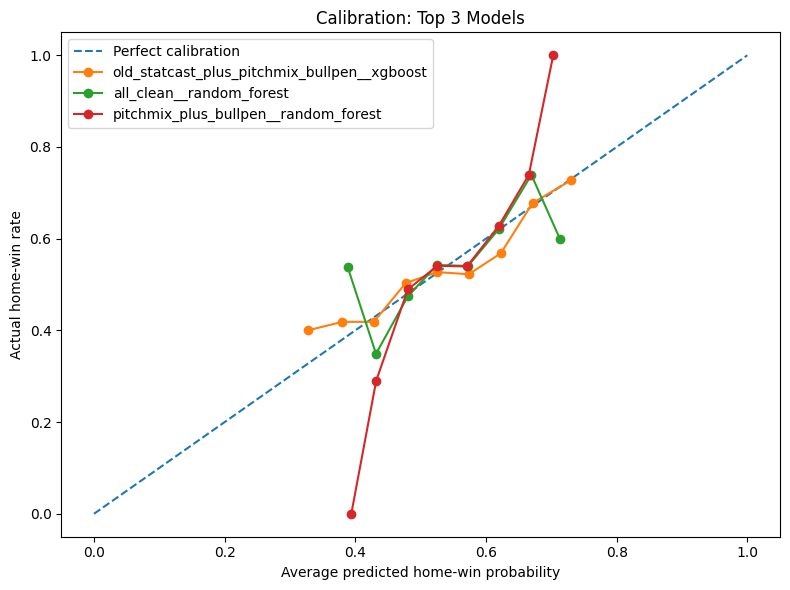

,model_name,games,ece_weighted_abs_error,mce_max_abs_error,avg_abs_error_unweighted
2,pitchmix_plus_bullpen__random_forest,1818,0.023230,0.393866,0.121227
0,all_clean__random_forest,1818,0.023546,0.150238,0.059073
1,old_statcast_plus_pitchmix_bullpen__xgboost,1818,0.027366,0.072529,0.029313


In [11]:
eligible = results_df[
    (~results_df['suspicious_metric'])
    & (results_df['model_name'] != 'constant_train_home_rate')
    & (results_df['model_name'].isin(fitted_models.keys()))
].copy()

eligible = eligible.sort_values(['log_loss', 'brier', 'roc_auc'], ascending=[True, True, False])
top_model_names = eligible['model_name'].head(3).tolist()

print('Top models:', top_model_names)
display(eligible.head(10))

for model_name in top_model_names:
    p = preds_by_name[model_name]
    pipe, cols = fitted_models[model_name]

    print()
    print('=' * 100)
    print('Model:', model_name)
    print('Feature count:', len(cols))
    display(results_df[results_df['model_name'].eq(model_name)])

    print()
    print('Classification report at 50% threshold:')
    print(classification_report(y_test, (p >= 0.5).astype(int), digits=3))

    print('Confusion matrix:')
    display(pd.DataFrame(
        confusion_matrix(y_test, (p >= 0.5).astype(int)),
        index=['actual_away', 'actual_home'],
        columns=['pred_away', 'pred_home'],
    ))

bins = [0, .35, .40, .45, .50, .55, .60, .65, .70, 1.0]
calib_frames = []

for model_name in top_model_names:
    p = preds_by_name[model_name]
    tmp = pd.DataFrame({'model_name': model_name, 'p': p, 'y': y_test.values})
    tmp['bucket'] = pd.cut(tmp['p'], bins=bins, include_lowest=True)

    tab = (
        tmp.groupby(['model_name', 'bucket'], observed=False)
        .agg(
            games=('y', 'size'),
            avg_pred_prob=('p', 'mean'),
            actual_home_win_rate=('y', 'mean'),
        )
        .reset_index()
    )
    tab['calibration_error'] = tab['actual_home_win_rate'] - tab['avg_pred_prob']
    calib_frames.append(tab)

calib_table_all = pd.concat(calib_frames, ignore_index=True) if calib_frames else pd.DataFrame()
display(calib_table_all)

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect calibration')

for model_name in top_model_names:
    plot_df = calib_table_all[
        (calib_table_all['model_name'].eq(model_name))
        & (calib_table_all['games'] > 0)
    ].dropna(subset=['avg_pred_prob', 'actual_home_win_rate'])

    plt.plot(
        plot_df['avg_pred_prob'],
        plot_df['actual_home_win_rate'],
        marker='o',
        label=model_name,
    )

plt.xlabel('Average predicted home-win probability')
plt.ylabel('Actual home-win rate')
plt.title('Calibration: Top 3 Models')
plt.legend()
plt.tight_layout()
plt.show()


def calibration_summary(calib_table: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for model_name, g in calib_table.groupby('model_name'):
        g = g.dropna(subset=['avg_pred_prob', 'actual_home_win_rate', 'calibration_error']).copy()
        total_games = g['games'].sum()
        if total_games == 0:
            continue

        ece = ((g['games'] / total_games) * g['calibration_error'].abs()).sum()
        mce = g['calibration_error'].abs().max()

        rows.append({
            'model_name': model_name,
            'games': int(total_games),
            'ece_weighted_abs_error': float(ece),
            'mce_max_abs_error': float(mce),
            'avg_abs_error_unweighted': float(g['calibration_error'].abs().mean()),
        })

    return pd.DataFrame(rows).sort_values('ece_weighted_abs_error')

calibration_summary_df = calibration_summary(calib_table_all)
display(calibration_summary_df)

In [12]:
shrink_rows = []

best_name = "old_statcast_plus_pitchmix_bullpen__xgboost"
p_raw = preds_by_name[best_name]

for shrink in [1.00, 0.95, 0.90, 0.85, 0.80, 0.75]:
    p_shrunk = 0.5 + shrink * (p_raw - 0.5)

    shrink_rows.append({
        "model_name": best_name,
        "shrink": shrink,
        "avg_pred": p_shrunk.mean(),
        "actual_rate": y_test.mean(),
        "log_loss": log_loss(y_test, p_shrunk),
        "brier": brier_score_loss(y_test, p_shrunk),
        "roc_auc": roc_auc_score(y_test, p_shrunk),
        "accuracy_50pct": accuracy_score(y_test, p_shrunk >= 0.5),
    })

shrink_df = pd.DataFrame(shrink_rows).sort_values(["log_loss", "brier"])
display(shrink_df)

,model_name,shrink,avg_pred,actual_rate,log_loss,brier,roc_auc,accuracy_50pct
4,old_statcast_plus_pitchmix_bullpen__xgboost,0.80,0.534045,0.529153,0.683232,0.245105,0.569429,0.548405
5,old_statcast_plus_pitchmix_bullpen__xgboost,0.75,0.531917,0.529153,0.683241,0.245107,0.569429,0.548405
3,old_statcast_plus_pitchmix_bullpen__xgboost,0.85,0.536173,0.529153,0.683309,0.245144,0.569429,0.548405
2,old_statcast_plus_pitchmix_bullpen__xgboost,0.90,0.538301,0.529153,0.683474,0.245224,0.569429,0.548405
1,old_statcast_plus_pitchmix_bullpen__xgboost,0.95,0.540428,0.529153,0.683729,0.245344,0.569429,0.548405
0,old_statcast_plus_pitchmix_bullpen__xgboost,1.00,0.542556,0.529153,0.684075,0.245505,0.569429,0.548405


## 10. Optional XGBoost hyperparameter tuning + overfitting curve

This section tunes one selected feature family using an inner chronological train/validation split while keeping the test set untouched.


In [ ]:
RUN_XGB_TUNING = True  # flip to True when you want to spend time tuning
TUNE_FAMILY = 'old_statcast_plus_pitchmix_bullpen'
N_TUNING_ITER = 40

if RUN_XGB_TUNING:
    assert XGBOOST_AVAILABLE, 'XGBoost unavailable.'
    assert TUNE_FAMILY in feature_sets, f'Unknown TUNE_FAMILY: {TUNE_FAMILY}'

    tune_cols = [c for c in feature_sets[TUNE_FAMILY] if c in model_base_cols and c in train_df.columns]
    print('Tuning family:', TUNE_FAMILY)
    print('Tuning feature count:', len(tune_cols))

    train_inner, val_inner = chronological_split(train_df, test_frac=0.20)
    y_train_inner = train_inner[TARGET_COL].astype(int)
    y_val_inner = val_inner[TARGET_COL].astype(int)

    imp = SimpleImputer(strategy='median', add_indicator=True)
    X_train_inner = imp.fit_transform(train_inner[tune_cols])
    X_val_inner = imp.transform(val_inner[tune_cols])

    param_space = {
        'max_depth': [2, 3, 4],
        'learning_rate': [0.01, 0.02, 0.03, 0.05],
        'min_child_weight': [5, 10, 20, 40],
        'subsample': [0.65, 0.75, 0.85, 0.95],
        'colsample_bytree': [0.50, 0.65, 0.80, 0.95],
        'gamma': [0.0, 0.25, 0.5, 1.0],
        'reg_alpha': [0.0, 0.05, 0.1, 0.5, 1.0],
        'reg_lambda': [1.0, 2.0, 5.0, 10.0],
    }

    samples = list(ParameterSampler(param_space, n_iter=N_TUNING_ITER, random_state=RANDOM_STATE))
    tuning_rows = []
    trained_trials = {}

    for i, params in enumerate(samples, start=1):
        model = XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            tree_method='hist',
            n_estimators=2500,
            early_stopping_rounds=75,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            **params,
        )

        model.fit(
            X_train_inner,
            y_train_inner,
            eval_set=[(X_train_inner, y_train_inner), (X_val_inner, y_val_inner)],
            verbose=False,
        )

        p_val = model.predict_proba(X_val_inner)[:, 1]

        tuning_rows.append({
            'trial': i,
            **params,
            'best_iteration': getattr(model, 'best_iteration', np.nan),
            'best_score': getattr(model, 'best_score', np.nan),
            'val_log_loss': log_loss(y_val_inner, p_val),
            'val_brier': brier_score_loss(y_val_inner, p_val),
            'val_auc': roc_auc_score(y_val_inner, p_val),
            'val_accuracy_50pct': accuracy_score(y_val_inner, p_val >= 0.5),
            'avg_pred': float(np.mean(p_val)),
            'actual_rate': float(np.mean(y_val_inner)),
        })

        trained_trials[i] = model
        if i % 5 == 0:
            print(f'Finished {i}/{len(samples)} trials')

    tuning_df = pd.DataFrame(tuning_rows).sort_values(
        ['val_log_loss', 'val_brier', 'val_auc'],
        ascending=[True, True, False],
    )
    display(tuning_df.head(20))

    best_trial = int(tuning_df.iloc[0]['trial'])
    best_tuned_model = trained_trials[best_trial]

    print('Best trial:', best_trial)
    print('Best iteration:', getattr(best_tuned_model, 'best_iteration', None))
    print('Best score:', getattr(best_tuned_model, 'best_score', None))

    evals = best_tuned_model.evals_result()
    train_logloss = evals['validation_0']['logloss']
    val_logloss = evals['validation_1']['logloss']

    plt.figure(figsize=(9, 5))
    plt.plot(train_logloss, label='Train log loss')
    plt.plot(val_logloss, label='Validation log loss')

    best_iter = getattr(best_tuned_model, 'best_iteration', None)
    if best_iter is not None:
        plt.axvline(best_iter, linestyle='--', label=f'Best iteration: {best_iter}')

    plt.xlabel('Boosting round')
    plt.ylabel('Log loss')
    plt.title(f'XGBoost overfitting curve: {TUNE_FAMILY}')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Set RUN_XGB_TUNING=True to run the tuning section.')

## 11. Export champion model bundle

Review leakage, calibration, and metrics before setting `APPROVE_EXPORT=True`.


In [13]:
APPROVE_EXPORT = True

CHAMPION_NAME = "old_statcast_plus_pitchmix_bullpen__xgboost"
PROBABILITY_SHRINK = 0.80
SHRINK_CENTER = 0.50

if APPROVE_EXPORT:
    import json
    import joblib
    from datetime import datetime, timezone
    from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score, accuracy_score

    assert CHAMPION_NAME in fitted_models, f"Champion not fitted: {CHAMPION_NAME}"

    champion_model, champion_cols = fitted_models[CHAMPION_NAME]
    p_raw = preds_by_name[CHAMPION_NAME]

    # Shrink probabilities toward the center to reduce overconfidence.
    p_shrunk = SHRINK_CENTER + PROBABILITY_SHRINK * (p_raw - SHRINK_CENTER)
    p_shrunk = np.clip(p_shrunk, 0.01, 0.99)

    model_dir = PROJECT_ROOT / "models"
    model_dir.mkdir(exist_ok=True)

    bundle = {
        "model_name": CHAMPION_NAME,
        "model": champion_model,
        "feature_cols": champion_cols,
        "target_col": TARGET_COL,
        "created_at_utc": datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
        "min_train_date": MIN_TRAIN_DATE,

        # Probability calibration/shrinkage settings used by production scorer
        "probability_shrink": PROBABILITY_SHRINK,
        "shrink_center": SHRINK_CENTER,
    }

    joblib.dump(bundle, model_dir / "mlb_moneyline_champion.joblib")

    meta = {
        "model_name": CHAMPION_NAME,
        "feature_count": len(champion_cols),

        # Raw model metrics
        "raw_test_log_loss": float(log_loss(y_test, p_raw)),
        "raw_test_brier": float(brier_score_loss(y_test, p_raw)),
        "raw_test_auc": float(roc_auc_score(y_test, p_raw)),
        "raw_test_accuracy_50pct": float(accuracy_score(y_test, p_raw >= 0.5)),

        # Shrunk production-probability metrics
        "test_log_loss": float(log_loss(y_test, p_shrunk)),
        "test_brier": float(brier_score_loss(y_test, p_shrunk)),
        "test_auc": float(roc_auc_score(y_test, p_shrunk)),
        "test_accuracy_50pct": float(accuracy_score(y_test, p_shrunk >= 0.5)),

        "probability_shrink": PROBABILITY_SHRINK,
        "shrink_center": SHRINK_CENTER,

        "train_min_date": str(train_df["official_date"].min()),
        "train_max_date": str(train_df["official_date"].max()),
        "test_min_date": str(test_df["official_date"].min()),
        "test_max_date": str(test_df["official_date"].max()),
    }

    with open(model_dir / "mlb_moneyline_champion_metadata.json", "w") as f:
        json.dump(meta, f, indent=2)

    print("Exported:", model_dir / "mlb_moneyline_champion.joblib")
    print("Exported:", model_dir / "mlb_moneyline_champion_metadata.json")

    print("\nRaw metrics:")
    print("Log loss:", meta["raw_test_log_loss"])
    print("Brier:", meta["raw_test_brier"])

    print("\nShrunk production metrics:")
    print("Log loss:", meta["test_log_loss"])
    print("Brier:", meta["test_brier"])

else:
    print("APPROVE_EXPORT is False. Review results first.")
    print("Suggested champion:", CHAMPION_NAME)
    print("Probability shrink:", PROBABILITY_SHRINK)
    print("Shrink center:", SHRINK_CENTER)

Exported: C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\models\mlb_moneyline_champion.joblib
Exported: C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\models\mlb_moneyline_champion_metadata.json

Raw metrics:
Log loss: 0.6840753803730706
Brier: 0.24550522841824415

Shrunk production metrics:
Log loss: 0.6832318077901152
Brier: 0.24510540733769673
